# **Capstone Project: A Bi-Objective Evolutionary Approach to Feature Selection for Customer Value Prediction in Fintech**

# *Data Preprocessing & Baseline Modelling*

## MBAI 5600G: Applied Integrative Analytics Capstone Project

### Group 7: Brennan Mason & Mohammad Shah
---

## Environment Setup

In [ ]:
# Specify base path to local directory
BASE_PATH = "/content/drive/Shareddrives/MBAI Capstone S S26 Group 7/"

In [ ]:
!pip install great_tables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.0/451.0 kB 27.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

Mounted at /content/drive


## Data Ingestion & Inspection

In [ ]:
import pandas as pd
import numpy as np

# Configure global display format
pd.options.display.float_format = '{:,.5f}'.format

# Define path
path = BASE_PATH + "p2p-customer-value-prediction/data/processed/cleaned_loans.csv"

# Load data
loans = pd.read_csv(path)

# Inspect head
loans.head()

,funded_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,...,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,rar,issue_yr,delinq_recency_bin
0,"7,000.00000",36,0.07890,A,A5,10.00000,MORTGAGE,"69,000.00000",Not Verified,Fully Paid,...,0.00000,"231,893.00000","29,326.00000","9,100.00000","24,693.00000",Cash,N,"7,126.31286",2015,Never Delinquent
1,"5,000.00000",36,0.06030,A,A1,1.00000,RENT,"37,000.00000",Verified,Fully Paid,...,0.00000,"11,423.00000","1,411.00000","8,200.00000","2,625.00000",Cash,N,"4,944.31630",2012,Never Delinquent
2,"10,000.00000",36,0.07120,A,A3,3.00000,RENT,"100,000.00000",Source Verified,Fully Paid,...,0.00000,"196,745.00000","143,072.00000","27,500.00000","161,126.00000",Cash,N,"9,830.12403",2014,Never Delinquent
3,"12,000.00000",36,0.05930,A,A1,NaN,RENT,"60,000.00000",Verified,Fully Paid,...,0.00000,"206,735.00000","12,162.00000","76,700.00000",0.00000,Cash,N,"11,681.85155",2015,Never Delinquent
4,"6,700.00000",36,0.05320,A,A1,3.00000,MORTGAGE,"69,000.00000",Not Verified,Fully Paid,...,0.00000,"204,505.00000","27,059.00000","52,600.00000","35,900.00000",Cash,N,"6,753.79570",2017,Never Delinquent


In [ ]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254328 entries, 0 to 254327
Data columns (total 71 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   funded_amnt                 254328 non-null  float64
 1   term                        254328 non-null  int64  
 2   int_rate                    254328 non-null  float64
 3   grade                       254328 non-null  object 
 4   sub_grade                   254328 non-null  object 
 5   emp_length                  239535 non-null  float64
 6   home_ownership              254328 non-null  object 
 7   annual_inc                  254328 non-null  float64
 8   verification_status         254328 non-null  object 
 9   loan_status                 254328 non-null  object 
 10  purpose                     254328 non-null  object 
 11  dti                         254265 non-null  float64
 12  delinq_2yrs                 254328 non-null  float64
 13  fico_range_low

In [ ]:
# Specify leaky features to drop
leaky_cols = [
    "total_pymnt",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "loan_status",
    "last_pymnt_amnt",  # Fixing lingering leakage
    "last_fico_range_low",
    "last_fico_range_high",
    "debt_settlement_flag"
]

# Drop leaky features
loans.drop(leaky_cols, axis=1, inplace=True)

## Data Preprocessing

In [ ]:
# Import required classes and functions for preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline, make_pipeline

In [ ]:
# Get lists of skewed and symmetric numeric features
num_cols = loans.select_dtypes(include=[np.number]).columns.tolist()
target_col = "rar"
num_feats = [col for col in num_cols if col != target_col]

skew_num_feats = [col for col in num_feats if abs(loans[col].skew()) > 1]  # Slight data leakage occurring here
sym_num_feats = [col for col in num_feats if col not in skew_num_feats]

> **Notes:**
> * Computing skewness on the entire dataset prior to CV splitting technically constitutes a slight form of data leakage
> * The current implementation is retained for the sake of simplicity (i.e., to avoid the definition of a complex custom class)
> * Given the large sample size of the dataset, the resultant stability of distribution moments (e.g., skewness), and the fact that skewness is merely being used to route features to the appropriate imputer (i.e., mean vs median strategy), the projected impact is negligible

In [ ]:
# Construct partial preprocessing pipeline for categorical features
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),  # Using mode imputation strategy for categorical features
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Construct full preprocessing pipeline for experimental condition 1 (i.e., without transformation)
raw_preprocessing_pipe = ColumnTransformer(
    transformers=[
        ("cat", cat_pipe, make_column_selector(dtype_include=object)),
        ("sym_num", SimpleImputer(strategy="mean"), sym_num_feats),  # Using mean imputation strategy for symmetric numeric features
        ("skew_num", SimpleImputer(strategy="median"), skew_num_feats)  # Using median imputation strategy for skewed numeric features (more robust)
    ],
    verbose_feature_names_out=False
)

# Construct partial preprocessing pipeline for symmetric numeric features with transformation
sym_num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("standardize", StandardScaler())
])

# Construct partial preprocessing pipeline for skewed numeric features with transformation
skew_num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("transform", PowerTransformer())  # Performs Yeo-Johnson transformation and then standard scaling
])

# Construct full preprocessing pipeline for subsequent experimental conditions (i.e., with transformation)
trans_preprocessing_pipe = ColumnTransformer(
    transformers=[
        ("cat", cat_pipe, make_column_selector(dtype_include=object)),
        ("sym_num", sym_num_pipe, sym_num_feats),
        ("skew_num", skew_num_pipe, skew_num_feats)
    ],
    verbose_feature_names_out=False
)

In [ ]:
# Separate feature matrix and target vector
X = loans.drop(target_col, axis=1)
y = loans[target_col].copy()

# Test preprocessing pipeline on full dataset
X_prep = raw_preprocessing_pipe.fit_transform(X)

# Get preprocessed df and inspect results
X_prep_df = pd.DataFrame(
    X_prep,
    columns=raw_preprocessing_pipe.get_feature_names_out(),
    index=X.index
)

X_prep_df.head()

,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,sub_grade_A1,sub_grade_A2,sub_grade_A3,...,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,1.00000,100.00000,1.00000,0.00000,"231,893.00000","29,326.00000","9,100.00000","24,693.00000"
1,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,100.00000,0.00000,0.00000,"11,423.00000","1,411.00000","8,200.00000","2,625.00000"
2,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,...,0.00000,0.00000,2.00000,100.00000,0.00000,0.00000,"196,745.00000","143,072.00000","27,500.00000","161,126.00000"
3,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,...,0.00000,0.00000,1.00000,100.00000,0.00000,0.00000,"206,735.00000","12,162.00000","76,700.00000",0.00000
4,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,...,0.00000,0.00000,3.00000,100.00000,0.00000,0.00000,"204,505.00000","27,059.00000","52,600.00000","35,900.00000"


In [ ]:
print(f"Shape after preprocessing: {X_prep_df.shape[0]:,} rows, {X_prep_df.shape[1]} columns")
print(f"\nFeatures after preprocessing: {X_prep_df.columns.tolist()}")

Shape after preprocessing: 254,328 rows, 126 columns

Features after preprocessing: ['grade_A', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G', 'sub_grade_A1', 'sub_grade_A2', 'sub_grade_A3', 'sub_grade_A4', 'sub_grade_A5', 'sub_grade_B1', 'sub_grade_B2', 'sub_grade_B3', 'sub_grade_B4', 'sub_grade_B5', 'sub_grade_C1', 'sub_grade_C2', 'sub_grade_C3', 'sub_grade_C4', 'sub_grade_C5', 'sub_grade_D1', 'sub_grade_D2', 'sub_grade_D3', 'sub_grade_D4', 'sub_grade_D5', 'sub_grade_E1', 'sub_grade_E2', 'sub_grade_E3', 'sub_grade_E4', 'sub_grade_E5', 'sub_grade_F1', 'sub_grade_F2', 'sub_grade_F3', 'sub_grade_F4', 'sub_grade_F5', 'sub_grade_G1', 'sub_grade_G2', 'sub_grade_G3', 'sub_grade_G4', 'sub_grade_G5', 'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Not Verified', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_car', 'purpose_credit

> **Notes:**
> * Final feature count after preprocessing is 126&mdash;5 features more than Machado & Karray's implementation (which had 121 features after DPT), but close enough given the available information

## Baseline Model Development & Evaluation

In [ ]:
from sklearn.model_selection import RepeatedKFold

# Define 5x2 CV procedure
cv = RepeatedKFold(n_splits=2, n_repeats=5, random_state=42)

# Specify eval metrics
scoring = ["r2", "neg_mean_absolute_error", "neg_mean_absolute_percentage_error"]

# Initialize dictionary to store eval metrics across conditions and models
eval_dict = {
    "Condition": [],
    "Model": [],
    "R-squared": [],
    "Adjusted R-squared": [],
    "MAE": [],
    "MAPE": [],
    "Fit Time (s)": [],
    "Score Time (s)": [],
    "Feature Count": []
}

# Define function to compute adjusted R-squared
def compute_adj_r2(r2, n_obs, n_feats):
  """
  Computes the Adjusted R-squared metric.

  Parameters:
  -----------
      - r2 (float): R-squared metric.
      - n_obs (int): Number of observations.
      - n_feats (int): Number of features.

  Returns:
  --------
      - float: Adjusted R-squared metric.
  """
  # Prevent div by zero
  if n_obs <= n_feats + 1:
    return np.nan

  return 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_feats - 1)

# Define function to get clean evaluation summary
def get_eval_summary(scores, X, cond_num, model_name):
  """
  Extracts, calculates, stores, and displays aggregate evaluation metrics from cross-validation.

  Parameters:
  -----------
      - scores (dict): Dictionary of cross-validation scores.
      - X (pd.DataFrame): Full feature matrix used in the experiment.
      - cond_num (int): Experimental condition number.
      - model_name (str): Name of the model/hybrid framework being evaluated.

  Returns:
  --------
      - None
  """
  # Get number of observations in validation set
  n_obs = len(X) / 2

  # Get number of features used by final regressor in pipeline
  if "estimator" in scores:
    try:
      # Extract number of features used during each fold and take average
      fold_feats = [est[-1].n_features_in_ for est in scores["estimator"]]
      n_feats = np.mean(fold_feats)
    except (AttributeError, IndexError):
      n_feats = X.shape[1]
  else:
    n_feats = X.shape[1]

  # Compute aggregate eval metrics
  r2 = round(scores["test_r2"].mean(), 5)
  adj_r2 = round(compute_adj_r2(r2, n_obs, n_feats), 5)
  mae = round(-scores["test_neg_mean_absolute_error"].mean(), 5)
  mape = round(-scores["test_neg_mean_absolute_percentage_error"].mean(), 5)
  fit_time = round(scores["fit_time"].mean(), 5)
  score_time = round(scores["score_time"].mean(), 5)

  # Store results in global eval dict
  eval_dict["Condition"].append(cond_num)
  eval_dict["Model"].append(model_name)
  eval_dict["R-squared"].append(r2)
  eval_dict["Adjusted R-squared"].append(adj_r2)
  eval_dict["MAE"].append(mae)
  eval_dict["MAPE"].append(mape)
  eval_dict["Fit Time (s)"].append(fit_time)
  eval_dict["Score Time (s)"].append(score_time)
  eval_dict["Feature Count"].append(n_feats)

  # Display results
  eval_df = pd.DataFrame({
      key: [val[-1]] for key, val in eval_dict.items() if key not in ["Condition", "Model"]
  }).T.reset_index().rename(columns={"index": "Metric", 0: "Value"})

  print(f"=== Results: Condition {cond_num} | {model_name} ===")
  display(eval_df)

### Experimental Condition 1
*No transformation, no clustering, & regression*

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate
import gc

tree_regr = make_pipeline(
    raw_preprocessing_pipe,  # Perform preprocessing without transformation
    DecisionTreeRegressor(
        max_depth=15,  # Cap number of splits
        random_state=42
    )
)

tree_scores = cross_validate(tree_regr, X, y, cv=cv, scoring=scoring, return_estimator=True)

get_eval_summary(tree_scores, X, cond_num=1, model_name="DT")

# Release memory
del tree_regr
del tree_scores
gc.collect();

=== Results: Condition 1 | DT ===


,Metric,Value
0,R-squared,0.65978
1,Adjusted R-squared,0.65944
2,MAE,"2,763.74941"
3,MAPE,0.41043
4,Fit Time (s),10.09391
5,Score Time (s),0.65764
6,Feature Count,126.00000


In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_regr = make_pipeline(
    raw_preprocessing_pipe,
    RandomForestRegressor(
        n_estimators=50,  # Reduce number of trees
        max_depth=15,  # Cap number of splits
        n_jobs=-1,  # Parallelize training
        max_samples=0.7,  # Train on 70% bootstrapped subsample per tree
        random_state=42
    )
)

forest_scores = cross_validate(forest_regr, X, y, cv=cv, scoring=scoring, return_estimator=True)

get_eval_summary(forest_scores, X, cond_num=1, model_name="RF")

del forest_regr
del forest_scores
gc.collect();

=== Results: Condition 1 | RF ===


,Metric,Value
0,R-squared,0.76628
1,Adjusted R-squared,0.76605
2,MAE,"2,602.21147"
3,MAPE,0.39914
4,Fit Time (s),151.58900
5,Score Time (s),1.35247
6,Feature Count,126.00000


In [ ]:
import xgboost as xgb

xgb_regr = make_pipeline(
    raw_preprocessing_pipe,
    xgb.XGBRegressor(
        tree_method="hist",  # Use histogram-based implementation
        n_jobs=-1,  # Use both CPU cores
        subsample=0.7,  # Train on 70% subsample (without replacement) per tree
        random_state=42
    )
)

xgb_scores = cross_validate(xgb_regr, X, y, cv=cv, scoring=scoring, return_estimator=True)

get_eval_summary(xgb_scores, X, cond_num=1, model_name="GB")

del xgb_regr
del xgb_scores
gc.collect();

=== Results: Condition 1 | GB ===


,Metric,Value
0,R-squared,0.75844
1,Adjusted R-squared,0.75820
2,MAE,"2,611.05901"
3,MAPE,0.39917
4,Fit Time (s),7.68316
5,Score Time (s),0.91636
6,Feature Count,126.00000


### Experimental Condition 2
*Transformation, no clustering, & regression*

In [ ]:
tree_regr = make_pipeline(
    trans_preprocessing_pipe,  # Switch to preprocessing with transformation
    DecisionTreeRegressor(
        max_depth=15,
        random_state=42
    )
)

tree_scores = cross_validate(tree_regr, X, y, cv=cv, scoring=scoring, return_estimator=True)

get_eval_summary(tree_scores, X, cond_num=2, model_name="DT")

del tree_regr
del tree_scores
gc.collect();

=== Results: Condition 2 | DT ===


,Metric,Value
0,R-squared,0.66020
1,Adjusted R-squared,0.65986
2,MAE,"2,762.60806"
3,MAPE,0.41020
4,Fit Time (s),16.56769
5,Score Time (s),0.99166
6,Feature Count,126.00000


In [ ]:
forest_regr = make_pipeline(
    trans_preprocessing_pipe,
    RandomForestRegressor(
        n_estimators=50,
        max_depth=15,
        n_jobs=-1,
        max_samples=0.7,
        random_state=42
    )
)

forest_scores = cross_validate(forest_regr, X, y, cv=cv, scoring=scoring, return_estimator=True)

get_eval_summary(forest_scores, X, cond_num=2, model_name="RF")

del forest_regr
del forest_scores
gc.collect();

=== Results: Condition 2 | RF ===


,Metric,Value
0,R-squared,0.76618
1,Adjusted R-squared,0.76595
2,MAE,"2,604.09857"
3,MAPE,0.39917
4,Fit Time (s),154.89061
5,Score Time (s),1.49802
6,Feature Count,126.00000


In [ ]:
xgb_regr = make_pipeline(
    trans_preprocessing_pipe,
    xgb.XGBRegressor(
        tree_method="hist",
        n_jobs=-1,
        subsample=0.7,
        random_state=42
    )
)

xgb_scores = cross_validate(xgb_regr, X, y, cv=cv, scoring=scoring, return_estimator=True)

get_eval_summary(xgb_scores, X, cond_num=2, model_name="GB")

del xgb_regr
del xgb_scores
gc.collect();

=== Results: Condition 2 | GB ===


,Metric,Value
0,R-squared,0.75799
1,Adjusted R-squared,0.75775
2,MAE,"2,612.97814"
3,MAPE,0.39921
4,Fit Time (s),14.48223
5,Score Time (s),1.16489
6,Feature Count,126.00000


### Experimental Condition 3
*Transformation, clustering, & regression*

#### Clustering Experimentation
*Preliminary experimentation with k-means clustering & DBSCAN to find optimal hyperparameters*

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns

# Transform full feature matrix
X_tr = trans_preprocessing_pipe.fit_transform(X)

# Get feature subset for clustering
clust_cols = ["funded_amnt", "dti", "grade", "delinq_recency_bin"]
feat_names = trans_preprocessing_pipe.get_feature_names_out()

clust_indices = [
    i for i, col in enumerate(feat_names)
    if "sub" not in col  # Disregard subgrade
    and any(clust_col in col for clust_col in clust_cols)
]

print("Features extracted for clustering:")
for feat_name in [feat_names[i] for i in clust_indices]:
  print(f"  - {feat_name}")

X_clust = X_tr[:, clust_indices]

# Randomly sample 20,000 observations for silhouette analysis
sample_size = 20_000
rng = np.random.RandomState(42)
sample_indices = rng.choice(X_clust.shape[0], size=sample_size, replace=False)

X_sample = X_clust[sample_indices]

print(f"\nShape of clustering sample: {X_sample.shape[0]:,} rows, {X_sample.shape[1]} columns")

Features extracted for clustering:
  - grade_A
  - grade_B
  - grade_C
  - grade_D
  - grade_E
  - grade_F
  - grade_G
  - delinq_recency_bin_12-36 Months
  - delinq_recency_bin_< 12 Months
  - delinq_recency_bin_> 36 Months
  - delinq_recency_bin_Never Delinquent
  - funded_amnt
  - dti

Shape of clustering sample: 20,000 rows, 13 columns


> **Notes:**
> * Machado & Karray define clusters based on the target variable (RAR) alongside multiple sources of risk, including "volatility of incomes, credit rating, and recency of delinquency"
> * We omit RAR from our cluster definition, as its inclusion would constitute blatant data leakage, rendering inference impracticable
> * We restrict our clustering features to proxy the above sources of risk as follows:
>   * **RAR:** As aforementioned, the inclusion of the RAR target variable results in data leakage. As such, we substitute `funded_amnt` as a suitable continuous pre-origination feature that is highly correlated with RAR and indicates the size of the loan.
>   * **Volatility of Incomes:** Although `beta` seems to be the most direct representation of income volatility, it is a direct mathematical component of RAR. As such, we substitute `dti` as a suitable continuous pre-origination feature that encodes borrower-specific risk.
>   * **Credit Rating:** We use the categorical `grade` feature to represent credit rating.
>   * **Recency of Delinquency:** Although `mths_since_last_delinq` seems to be the most direct representation of delinquency recency, it is marked by extensive missingness (> 50%). Retaining this variable for clustering would thus require imputation with a measure of central tendency (i.e., mean/median)&mdash;an excessively crude approach given the seemingly structural nature of the missingness (whereby nulls represent borrowers who have never been delinquent). As such, we use the discretized `delinq_recency_bin` to represent recency of delinquency.

=== Silhouette Score Summary | K-Means ===
Average Silhouette Score for k = 2: 0.20711
Average Silhouette Score for k = 3: 0.19133
Average Silhouette Score for k = 4: 0.16404
Average Silhouette Score for k = 5: 0.15045
Average Silhouette Score for k = 6: 0.17365
Average Silhouette Score for k = 7: 0.15206
Average Silhouette Score for k = 8: 0.15544
Average Silhouette Score for k = 9: 0.16455
Average Silhouette Score for k = 10: 0.15350



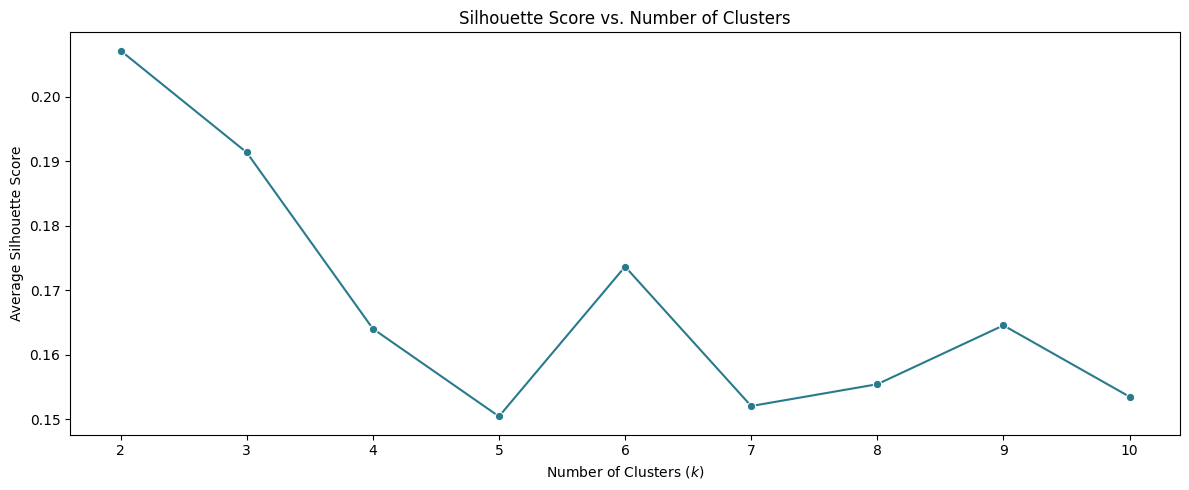

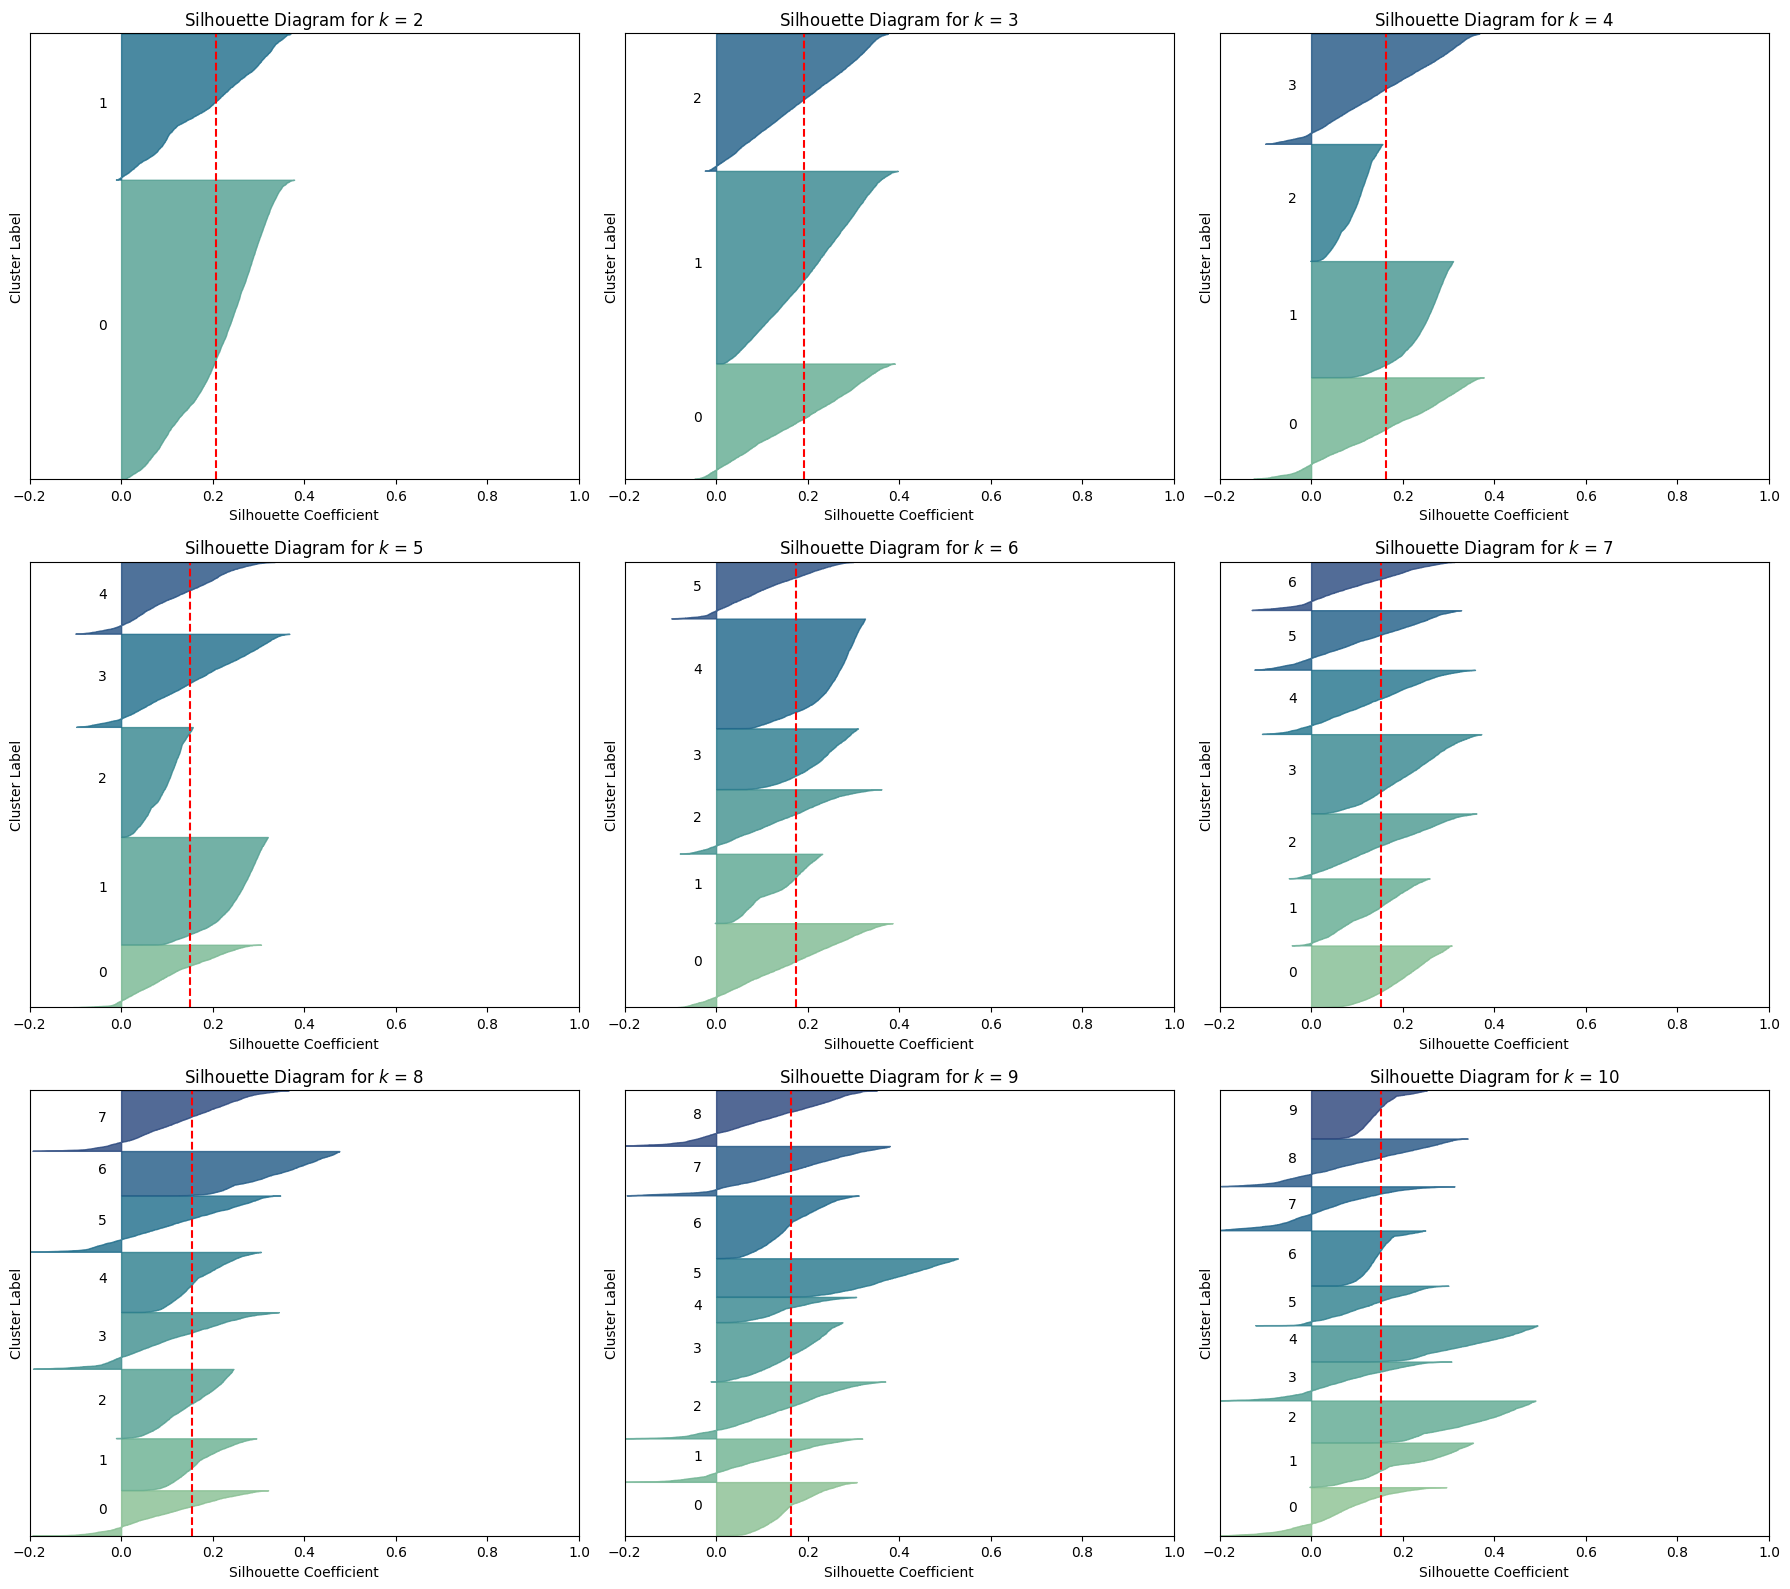

In [ ]:
# Evaluate clustering quality for different values of k
sil_data = []
k_vals = range(2, 11)  # Testing k values ranging from 2 to 10 as per M&K

print(f"=== Silhouette Score Summary | K-Means ===")
for k in k_vals:
  kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
  clust_labels = kmeans.fit_predict(X_sample)

  # Compute silhouette scores
  sil_vals = silhouette_samples(X_sample, clust_labels)
  sil_avg = silhouette_score(X_sample, clust_labels)

  # Store for plotting
  sil_data.append({
      "k": k,
      "sil_avg": sil_avg,
      "sil_vals": sil_vals,
      "clust_labels": clust_labels
  })

  print(f"Average Silhouette Score for k = {k}: {sil_avg:.5f}")

# Print blank line for spacing
print()

# Plot silhouette score vs k
fig, ax = plt.subplots(figsize=(12, 5))
avg_sil_scores = [data["sil_avg"] for data in sil_data]

sns.lineplot(
    x=k_vals,
    y=avg_sil_scores,
    marker="o",
    color=sns.color_palette("crest")[3],
    ax=ax
)

ax.set_title(f"Silhouette Score vs. Number of Clusters")
ax.set_xlabel(r"Number of Clusters ($k$)")
ax.set_ylabel("Average Silhouette Score")
ax.set_xticks(k_vals)

plt.tight_layout()
plt.show()

# Print blank line for spacing
print()

# Plot silhouette diagrams for each value of k
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for i, data in enumerate(sil_data):
  k = data["k"]
  sil_avg = data["sil_avg"]
  sil_vals = data["sil_vals"]
  clust_labels = data["clust_labels"]

  ax = axes[i]
  y_lower = 10
  colors = sns.color_palette("crest", n_colors=k)

  for j in range(k):
    # Get silhouette scores for the current cluster
    clust_sil_vals = sil_vals[clust_labels == j]
    clust_sil_vals.sort()

    size_j = clust_sil_vals.shape[0]
    y_upper = y_lower + size_j

    color = colors[j]
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        clust_sil_vals,
        facecolor=color,
        edgecolor=color,
        alpha=0.8
    )

    # Label the current cluster in the middle of the silhouette shape
    ax.text(-0.05, y_lower + 0.5 * size_j, str(j))

    # Compute new y_lower for next cluster
    y_lower = y_upper + 10

  ax.set_title(rf"Silhouette Diagram for $k$ = {k}")
  ax.set_xlabel("Silhouette Coefficient")
  ax.set_ylabel("Cluster Label")
  ax.axvline(x=sil_avg, color="red", linestyle="--")  # Plot dashed line representing average silhouette score
  ax.set_yticks([])
  ax.set_xlim([-0.2, 1])
  ax.set_ylim([0, sample_size + (k + 1) * 10])

plt.tight_layout()
plt.show()

> **Silhouette Analysis:**
> * Based on the empirical results shown above, we select $k = 3$ as the optimal number of clusters
> * Our rationale for this selection is as follows:
>   * The global average silhouette scores for all tested values of $k$ are relatively low, ranging from ~0.15 to ~0.21. This suggests poor separation between clusters, which is expected given our feature space's composition of continuous financial variables and one-hot encoded categorical features
>   * The highest global average silhouette score of ~0.21 is obtained with only 2 clusters, but 3 clusters trails closely behind at ~0.19, and the most precipitous drop occurs from $k = 3$ to $k = 4$
>   * When $k = 3$, the number of instances in each cluster is more uniformly distributed than when $k = 2$
>   * When $k = 3$, the proportion of instances extending beyond the global average is more balanced than when $k = 2$
>   * When $k = 4$, one of the clusters is comprised exclusively of instances that fall short of the global average, and two of the other clusters contain instances extending deeply into negative territory
>   * Machado & Karray found $k = 3$ to be optimal in their study

=== Silhouette Score Summary | DBSCAN ===
MinPts = 10 | Clusters Found = 25 | Avg Silhouette Score = 0.15486
MinPts = 30 | Clusters Found = 21 | Avg Silhouette Score = 0.11522
MinPts = 50 | Clusters Found = 15 | Avg Silhouette Score = 0.14756



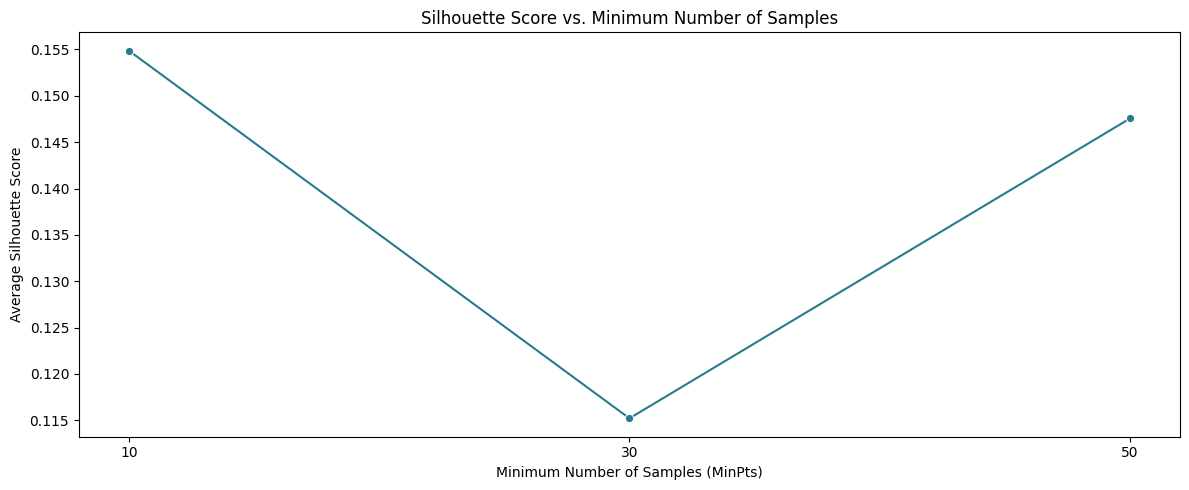

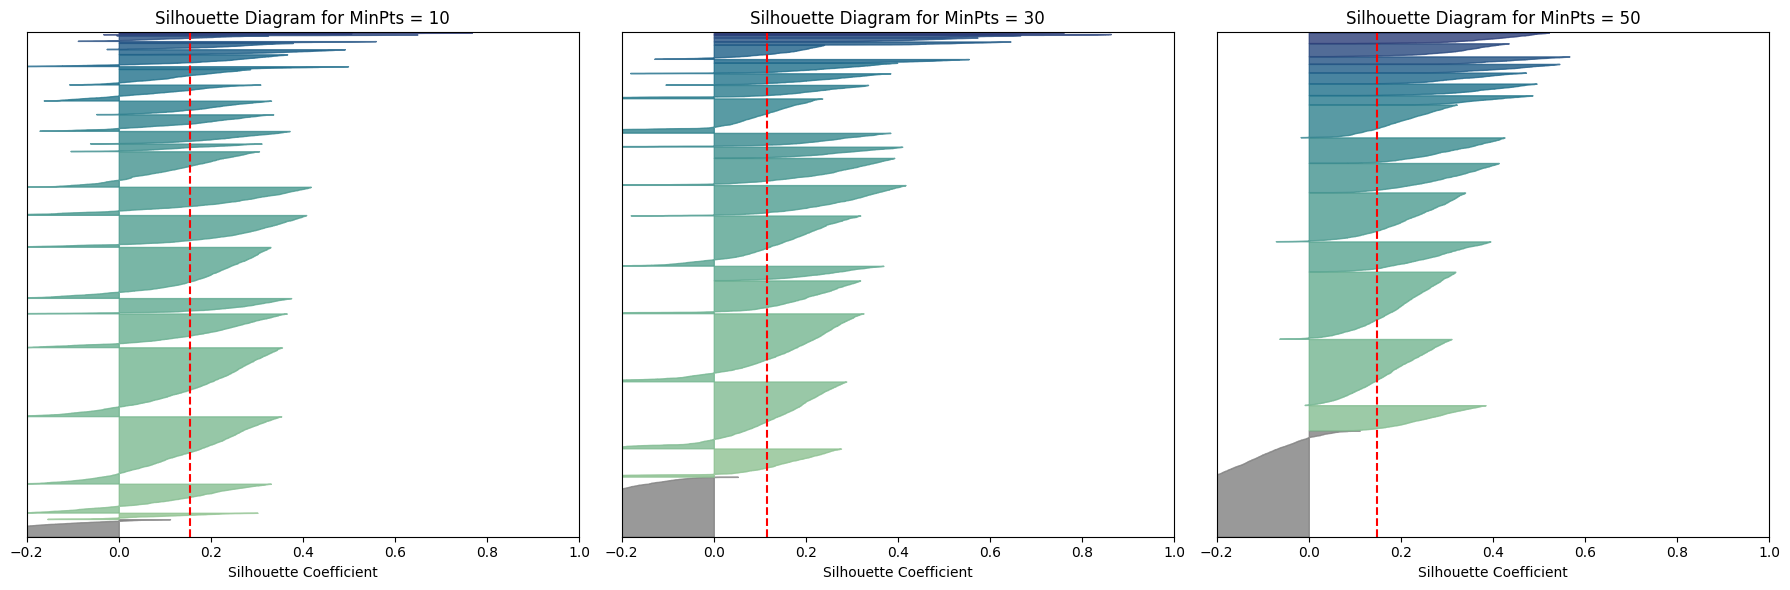

In [ ]:
# Evaluate clustering quality for different values of MinPts
sil_data = []
eps = 0.5  # Keeping epsilon fixed at 0.5 as per M&K
min_pts_vals = [10, 30, 50]  # Testing MinPts values of 10, 30, and 50 as per M&K

print(f"=== Silhouette Score Summary | DBSCAN ===")
for n in min_pts_vals:
  dbscan = DBSCAN(eps=eps, min_samples=n)
  clust_labels = dbscan.fit_predict(X_sample)

  # Compute number of clusters identified
  unique_labels = np.unique(clust_labels)
  n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)  # Ignoring noise label (-1)

  # If atleast 2 clusters exist, compute silhouette scores
  if len(unique_labels) > 1:
    sil_vals = silhouette_samples(X_sample, clust_labels)
    sil_avg = silhouette_score(X_sample, clust_labels)
  else:
    sil_vals = np.zeros(X_sample.shape[0])
    sil_avg = -1.0

  # Store for plotting
  sil_data.append({
      "min_samples": n,
      "n_clusters": n_clusters,
      "sil_avg": sil_avg,
      "sil_vals": sil_vals,
      "clust_labels": clust_labels
  })

  print(f"MinPts = {n:2d} | Clusters Found = {n_clusters:2d} | Avg Silhouette Score = {sil_avg:.5f}")

# Print blank line for spacing
print()

# Plot silhouette score for each value of MinPts
fig, ax = plt.subplots(figsize=(12, 5))
avg_sil_scores = [data["sil_avg"] for data in sil_data]

sns.lineplot(
    x=min_pts_vals,
    y=avg_sil_scores,
    marker="o",
    color=sns.color_palette("crest")[3],
    ax=ax
)

ax.set_title(f"Silhouette Score vs. Minimum Number of Samples")
ax.set_xlabel("Minimum Number of Samples (MinPts)")
ax.set_ylabel("Average Silhouette Score")
ax.set_xticks(min_pts_vals)

plt.tight_layout()
plt.show()

# Print blank line for spacing
print()

# Plot silhouette diagrams for each value of MinPts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, data in enumerate(sil_data):
  n = data["min_samples"]
  n_clusters = data["n_clusters"]
  sil_avg = data["sil_avg"]
  sil_vals = data["sil_vals"]
  clust_labels = data["clust_labels"]

  ax = axes[i]
  y_lower = 10
  unique_labels = np.unique(clust_labels)
  colors = sns.color_palette("crest", n_colors=len(unique_labels))

  for j, c in enumerate(unique_labels):
    # Get silhouette scores for the current cluster
    clust_sil_vals = sil_vals[clust_labels == c]
    clust_sil_vals.sort()

    size_j = clust_sil_vals.shape[0]
    y_upper = y_lower + size_j

    color = "gray" if c == -1 else colors[j]
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        clust_sil_vals,
        facecolor=color,
        edgecolor=color,
        alpha=0.8
    )

    # Label the current cluster in the middle of the silhouette shape (commented out for legibility)
    # label_text = "Noise" if c == -1 else str(c)
    # ax.text(-0.05, y_lower + 0.5 * size_j, label_text)

    # Compute new y_lower for next cluster
    y_lower = y_upper + 10

  ax.set_title(f"Silhouette Diagram for MinPts = {n}")
  ax.set_xlabel("Silhouette Coefficient")
  # ax.set_ylabel("Cluster Label")
  ax.axvline(x=sil_avg, color="red", linestyle="--")  # Plot dashed line representing average silhouette score
  ax.set_yticks([])
  ax.set_xlim([-0.2, 1])
  ax.set_ylim([0, sample_size + (len(unique_labels) + 1) * 10])

plt.tight_layout()
plt.show()

> **Silhouette Analysis:**
> * Based on the empirical results shown above, we elect to eliminate DBSCAN from our subsequent experimentation
> * For the hyperparameter combinations (i.e., $\epsilon = 0.5$, $MinPts \in \{10, 30, 50\}$) utilized by Machado & Karray, DBSCAN fails to find meaningful density groupings in this feature space, instead identifying an unmanageable proliferation of highly fragmented micro-clusters
>   * This finding contrasts with Machado & Karray's study, which reports a fixed $k = 7$ for DBSCAN in its evaluation tables&mdash;a seeming methodological contradiction, given that DBSCAN cannot be explicitly configured to group data into a pre-defined number of clusters $k$
>   * Using these 15-25 fragmented micro-clusters to train 15-25 separate regressors within a hybrid framework would severely erode the statistical power of the resultant models (due to the associated reduction in training sample size)

#### Hybrid Estimator Class Construction

In [ ]:
import scipy.sparse as sp
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.utils.validation import check_is_fitted

# Define custom class to implement the hybrid clustering-then-regression framework
class HybridClusterRegressor(BaseEstimator, RegressorMixin):
  """
  A custom hybrid estimator that clusters data based on the specified clustering features, drops the clustering features,
  and trains a separate regressor for each identified cluster.
  """
  def __init__(self, clusterer, base_regressor, clust_indices):
    """
    Parameters:
    -----------
        - clusterer: An instantiated scikit-learn clustering object (e.g., KMeans).
        - base_regressor: An instantiated scikit-learn regressor object (e.g., DecisionTreeRegressor).
        - clust_indices: List of integer column indices to be used for clustering.
    """
    self.clusterer = clusterer
    self.base_regressor = base_regressor
    self.clust_indices = clust_indices

  def fit(self, X, y):
    # Convert target vector to NumPy array if required
    y = np.asarray(y)

    # Isolate clustering features and fit clusterer
    X_clust = X[:, self.clust_indices]
    self.clusterer.fit(X_clust)

    # Get cluster labels for training set
    if hasattr(self.clusterer, "labels_"):
      clust_labels = self.clusterer.labels_
    else:
      clust_labels = self.clusterer.predict(X_clust)

    # Drop clustering features to create feature set for regression
    self.reg_indices_ = [i for i in range(X.shape[1]) if i not in self.clust_indices]
    X_reg = X[:, self.reg_indices_]
    self.n_features_in_ = X_reg.shape[1]

    # Train separate cloned regressor for each cluster
    self.regressors_ = {}
    unique_clusters = np.unique(clust_labels)

    for cluster in unique_clusters:
      # Filter for observations in current cluster
      mask = (clust_labels == cluster)
      X_clust = X_reg[mask]
      y_clust = y[mask]

      reg_clust = clone(self.base_regressor)
      reg_clust.fit(X_clust, y_clust)
      self.regressors_[cluster] = reg_clust

    self.is_fitted_ = True
    return self

  def predict(self, X):
    # Ensure the model is fitted
    check_is_fitted(self, "is_fitted_")

    # Isolate clustering features and assign points to clusters
    X_clust = X[:, self.clust_indices]
    cluster_labels = self.clusterer.predict(X_clust)

    # Drop clustering features for inference
    X_reg = X[:, self.reg_indices_]

    # Initialize empty array to store predictions
    preds = np.zeros(X.shape[0])

    # Route observations to their appropriate regressors
    for cluster, regressor in self.regressors_.items():
      mask = (cluster_labels == cluster)
      if np.any(mask):
        preds[mask] = regressor.predict(X_reg[mask])

    return preds

#### Hybrid Model Development

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate
import gc

kmeans_clust = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    random_state=42
)

tree_regr = DecisionTreeRegressor(
    max_depth=15,
    random_state=42
)

hybrid_clust_regr = HybridClusterRegressor(
    clusterer=kmeans_clust,
    base_regressor=tree_regr,
    clust_indices=clust_indices
)

hybrid_tree_pipe = make_pipeline(
    trans_preprocessing_pipe,
    hybrid_clust_regr
)

hybrid_tree_scores = cross_validate(hybrid_tree_pipe, X, y, cv=cv, scoring=scoring, return_estimator=True)

get_eval_summary(hybrid_tree_scores, X, cond_num=3, model_name="KM + DT")

del tree_regr
del hybrid_clust_regr
del hybrid_tree_pipe
del hybrid_tree_scores
gc.collect();

=== Results: Condition 3 | KM + DT ===


,Metric,Value
0,R-squared,0.41724
1,Adjusted R-squared,0.41672
2,MAE,"5,066.65637"
3,MAPE,0.76599
4,Fit Time (s),16.81288
5,Score Time (s),1.07776
6,Feature Count,113.00000


In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_regr = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    n_jobs=-1,
    max_samples=0.7,
    random_state=42
)

hybrid_clust_regr = HybridClusterRegressor(
    clusterer=kmeans_clust,
    base_regressor=forest_regr,
    clust_indices=clust_indices
)

hybrid_forest_pipe = make_pipeline(
    trans_preprocessing_pipe,
    hybrid_clust_regr
)

hybrid_forest_scores = cross_validate(hybrid_forest_pipe, X, y, cv=cv, scoring=scoring, return_estimator=True)

get_eval_summary(hybrid_forest_scores, X, cond_num=3, model_name="KM + RF")

del forest_regr
del hybrid_clust_regr
del hybrid_forest_pipe
del hybrid_forest_scores
gc.collect();

=== Results: Condition 3 | KM + RF ===


,Metric,Value
0,R-squared,0.60578
1,Adjusted R-squared,0.60543
2,MAE,"4,341.80815"
3,MAPE,0.70868
4,Fit Time (s),144.07088
5,Score Time (s),1.94105
6,Feature Count,113.00000


In [ ]:
import xgboost as xgb

xgb_regr = xgb.XGBRegressor(
    tree_method="hist",
    n_jobs=-1,
    subsample=0.7,
    random_state=42
)

hybrid_clust_regr = HybridClusterRegressor(
    clusterer=kmeans_clust,
    base_regressor=xgb_regr,
    clust_indices=clust_indices
)

hybrid_xgb_pipe = make_pipeline(
    trans_preprocessing_pipe,
    hybrid_clust_regr
)

hybrid_xgb_scores = cross_validate(hybrid_xgb_pipe, X, y, cv=cv, scoring=scoring, return_estimator=True)

get_eval_summary(hybrid_xgb_scores, X, cond_num=3, model_name="KM + GB")

del xgb_regr
del hybrid_clust_regr
del hybrid_xgb_pipe
del hybrid_xgb_scores
gc.collect();

=== Results: Condition 3 | KM + GB ===


,Metric,Value
0,R-squared,0.58976
1,Adjusted R-squared,0.58940
2,MAE,"4,382.82008"
3,MAPE,0.69152
4,Fit Time (s),18.20652
5,Score Time (s),1.27942
6,Feature Count,113.00000


### Evaluation Summary

In [ ]:
from great_tables import GT, loc, md

# Create eval summary df
eval_df = pd.DataFrame(eval_dict)

# Create clean eval summary table
eval_tbl = (
    GT(eval_df)
    .tab_header(
        title="Performance Summary by Condition & Model",
        subtitle="10-Fold Cross-Validation Evaluation Results"
    )
    .tab_spanner(
        label="Experiment Configuration",
        columns=["Condition", "Model"]
    )
    .tab_spanner(
        label="Evaluation Metrics",
        columns=["R-squared", "Adjusted R-squared", "MAE", "MAPE", "Fit Time (s)", "Score Time (s)", "Feature Count"],
    )
    .fmt_number(
        columns=["R-squared", "Adjusted R-squared"],
        decimals=5
    )
    .fmt_number(
        columns=["MAE", "Fit Time (s)", "Score Time (s)"],
        decimals=2,
        use_seps=True
    )
    .fmt_percent(
        columns=["MAPE"]
    )
    .fmt_integer(
        columns=["Feature Count"]
    )
    .tab_footnote(
        footnote="All evaluation metrics are averaged across 10 (5x2) cross-validation folds. Temporal metrics are measured in seconds.",
        locations=loc.spanner_labels(ids=["Evaluation Metrics"])
    )
    .tab_footnote(
        footnote="Feature count indicates the inputs provided to the supervised regressor, excluding features strictly utilized for clustering.",
        locations=loc.column_labels(columns=["Feature Count"])
    )
    .tab_footnote(
        footnote=md("A hyperparameter of *k*=3 was utilized for the *k*-means clustering algorithm across all hybrid frameworks."),
        locations=loc.body(
            columns=["Model"],
            rows=lambda x: x["Model"].isin(["KM + DT", "KM + RF", "KM + GB"])
        )
    )
    .cols_align(
        align="left",
        columns=["Condition"]
    )
    .cols_label(
        **{
            "Fit Time (s)": "Fit Time",
            "Score Time (s)": "Score Time"
        }
    )
    .opt_row_striping()
)

eval_tbl.show()

Performance Summary by Condition & Model 
 
 
 10-Fold Cross-Validation Evaluation Results 
 
 
 
 Experiment Configuration 
 
 
 Evaluation Metrics 1 
 
 
 
 Condition 
 Model 
 R-squared 
 Adjusted R-squared 
 MAE 
 MAPE 
 Fit Time 
 Score Time 
 Feature Count 2 
 
 
 
 
 1 
 DT 
 0.65978 
 0.65944 
 2,763.75 
 41.04% 
 10.09 
 0.66 
 126 
 
 
 1 
 RF 
 0.76628 
 0.76605 
 2,602.21 
 39.91% 
 151.59 
 1.35 
 126 
 
 
 1 
 GB 
 0.75844 
 0.75820 
 2,611.06 
 39.92% 
 7.68 
 0.92 
 126 
 
 
 2 
 DT 
 0.66020 
 0.65986 
 2,762.61 
 41.02% 
 16.57 
 0.99 
 126 
 
 
 2 
 RF 
 0.76618 
 0.76595 
 2,604.10 
 39.92% 
 154.89 
 1.50 
 126 
 
 
 2 
 GB 
 0.75799 
 0.75775 
 2,612.98 
 39.92% 
 14.48 
 1.16 
 126 
 
 
 3 
 KM + DT 3 
 0.41724 
 0.41672 
 5,066.66 
 76.60% 
 16.81 
 1.08 
 113 
 
 
 3 
 KM + RF 3 
 0.60578 
 0.60543 
 4,341.81 
 70.87% 
 144.07 
 1.94 
 113 
 
 
 3 
 KM + GB 3 
 0.58976 
 0.58940 
 4,382.82 
 69.15% 
 18.21 
 1.28 
 113 
 
 
 1 All evaluation metrics are averaged across 10 (5x2) cross-validation folds. Temporal metrics are measured in seconds. 2 Feature count indicates the inputs provided to the supervised regressor, excluding features strictly utilized for clustering. 3 A hyperparameter of k =3 was utilized for the k -means clustering algorithm across all hybrid frameworks.

In [ ]:
eval_df.groupby("Condition")["R-squared"].mean().sort_values(ascending=False)

,R-squared
Condition,
1,0.72817
2,0.72812
3,0.53759


In [ ]:
import plotly.graph_objects as go

eval_df["Condition + Model"] = "EC" + eval_df["Condition"].astype(str) + " - " + eval_df["Model"]
eval_df.sort_values("R-squared", ascending=True, inplace=True)

# Plot R-squared by condition and model
fig = go.Figure()

fig.add_trace(go.Bar(
    x=eval_df["R-squared"],
    y=eval_df["Condition + Model"],
    orientation="h",
    marker=dict(color="steelblue")
))

fig.update_layout(
    title="Coefficient of Determination (<i>R²</i>) by Condition & Model",
    xaxis_title=r"Coefficient of Determination (<i>R²</i>)",
    template="seaborn",
    font=dict(
        family="Helvetica Neue, sans-serif",
        color="#666666"
    ),
    width=1000,
    height=600
)

fig.update_traces(
    texttemplate="%{x:.4f}",
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(color="white")
)

fig.update_xaxes(tickformat=".1f", ticklabelstandoff=5)
fig.update_yaxes(ticklabelstandoff=5)

fig.show()

In [ ]:
eval_df.sort_values("Fit Time (s)", ascending=True, inplace=True)

# Plot training time by condition and model
fig = go.Figure()

fig.add_trace(go.Bar(
    x=eval_df["Fit Time (s)"],
    y=eval_df["Condition + Model"],
    orientation="h",
    marker=dict(color="steelblue")
))

fig.update_layout(
    title="Training Time by Condition & Model",
    xaxis_title="Training Time (Average Seconds per Cross-Validation Fold)",
    template="seaborn",
    font=dict(
        family="Helvetica Neue, sans-serif",
        color="#666666"
    ),
    width=1000,
    height=600
)

fig.update_traces(
    texttemplate="%{x:.2f}",
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(color="white")
)

fig.update_xaxes(tickformat=".0f", ticklabelstandoff=5)
fig.update_yaxes(ticklabelstandoff=5)

fig.show()

## Data Export

In [ ]:
import pickle

path = BASE_PATH + "p2p-customer-value-prediction/outputs/eval_dict.pkl"

with open(path, "wb") as f:
  pickle.dump(eval_dict, f)